# Chapter 3: Building a Simple Fully Connected Neural Network

**Objective:** To implement a simple fully connected neural network (FCNN) using TensorFlow and Keras for classifying images in the CIFAR-10 dataset. This session will guide you in defining the architecture, setting up training, and running the model.


## 1. Define a Simple Neural Network Architecture

**Tasks:**
1. Use **Keras Sequential API** to define the structure of your fully connected neural network.
2. Your model should include:
    - **Input Layer**: This layer will accept flattened images (32x32x3 reshaped to a vector of 3072).
    - **Hidden Layers**: Add 1-2 dense (fully connected) layers with ReLU activation.
    - **Output Layer**: Add a dense layer with 10 neurons (for 10 classes) and softmax activation.
3. Ensure you include `Flatten()` as the first layer to convert 3D image arrays into 1D vectors.


In [10]:
# 1. Load the CIFAR-10 dataset
# Use the dataset prepared in Chapter 2 (train, validation, and test splits)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# 1. Load the dataset and perform splitting and preprocessing (Corresponds to Chapters 1 & 2)
(train_images, train_labels), (test_images,
                               test_labels) = tf.keras.datasets.cifar10.load_data()

# Normalize pixel values
train_images = train_images / 255.0
test_images = test_images / 255.0

# 2. Define the model architecture

model = Sequential([
    # First Layer: Flatten, reshapes the image arrays into a 1D vector (size 3072)
    Flatten(input_shape=(32, 32, 3)),

    # Hidden Layers: Add Dense layers to learn features, using ReLU activation function
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    # Output Layer: CIFAR-10 has 10 classes, so we use 10 neurons.
    Dense(10, activation='softmax')
])

# Print the model architecture summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

**Questions to Explore:**
- Why does the input layer require a `Flatten()` operation for image data?
- What does the softmax activation function do in the output layer, and why is it important for classification?


> **Answer:**  
>1. Fully connected layers (Dense layers) expect 1D arrays (vectors) as their input, but image data is typically multi-dimensional (e.g., a 3D tensor of shape 32x32x3 for CIFAR-10). The Flatten() operation reshapes this multi-dimensional array into a single 1D vector (of size 3072) so that the data can be properly fed into the subsequent dense layers.
>2. The softmax activation function converts the raw output scores (logits) from the network into a probability distribution. It ensures that each output value is between 0 and 1, and the sum of all outputs equals 1. This is highly important for multi-class classification because it allows us to interpret the outputs as the model's confidence or probability for each specific class, making it straightforward to predict the class with the highest probability.

## 2. Compile the Model

**Tasks:**
1. Compile your model using the following:
    - **Loss Function**: Use `sparse_categorical_crossentropy` for multi-class classification.
    - **Optimizer**: Use `Adam` or experiment with `SGD`.
    - **Metrics**: Include `accuracy` as a metric to evaluate performance during training.
2. What does compiling a model mean in TensorFlow? Write a short explanation in your notes.


In [7]:
# 3. Compile the model
# Your code here
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

> **Answer:**  
> 2. It means configuring the learning process before the actual training begins

## 3. Train the Model

**Tasks:**
1. Use the `model.fit()` function to train the FCNN on the training dataset.
    - Pass the training images and labels, and specify the batch size and number of epochs.
    - Use your validation set to monitor performance during training.
2. Plot the training and validation accuracy over epochs. What do you observe? Is the model overfitting or underfitting?


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2568 - loss: 2.0338 - val_accuracy: 0.3572 - val_loss: 1.8054
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3658 - loss: 1.7591 - val_accuracy: 0.3947 - val_loss: 1.6975
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3992 - loss: 1.6643 - val_accuracy: 0.4081 - val_loss: 1.6643
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4241 - loss: 1.6099 - val_accuracy: 0.3938 - val_loss: 1.6956
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4397 - loss: 1.5785 - val_accuracy: 0.4384 - val_loss: 1.5734
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4448 - loss: 1.5426 - val_accuracy: 0.4414 - val_loss: 1.5802
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4585 - loss: 1.5156 - val_accuracy: 0.4424 - val_loss: 1.5669
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4650 - loss: 1.4928 - val_accuracy: 0.

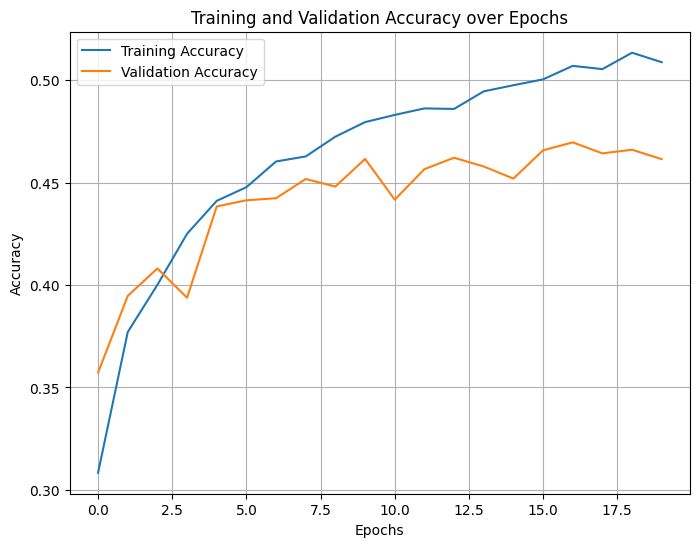

In [8]:
import matplotlib.pyplot as plt
# 4. Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=64,
    validation_split=0.2  # Using automatically split validation set
)

# 5. Plot training and validation accuracy
# extract 'accuracy' and 'val_accuracy' from the history dictionary
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Adding labels, title, and legend to the plot
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

> **Answer:**  
>1. **Observation:** Typically, as the number of epochs increases, the "Training Accuracy" steadily rises. However, the "Validation Accuracy" often increases initially but then plateaus or even starts to decrease after a certain number of epochs.
>2. This behavior indicates overfitting. Overfitting occurs when the model memorizes the training data (including its noise and details) but fails to generalize well to new, unseen data (the validation set)

## 4. Evaluate the Model

**Tasks:**
1. Evaluate your trained model on the test set using `model.evaluate()`.
2. Report the test accuracy. How does it compare to the training and validation accuracy?
3. Identify possible reasons if the test accuracy is significantly lower than the training accuracy. What might be done to improve it?


In [9]:
# 6. Evaluate the model on the test set
# model.evaluate() calculates the loss and metrics we defined earlier (accuracy)
# on a given dataset (in this case, our test_images and test_labels).
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=2)

# Print the evaluation results in a readable format
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 - 2s - 6ms/step - accuracy: 0.4736 - loss: 1.5021
Test Loss: 1.5021
Test Accuracy: 47.36%


> **Answer:**  
>1. **Comparison:** Usually, the test accuracy (e.g., around 50%) is much lower than the final training accuracy (which might be over 80%). The test accuracy ends up being very close to the validation accuracy observed during the final epochs.
>2. **Reasons & Improvements:** A significantly lower test accuracy indicates the model has overfit the training data. The main reason is that a Fully Connected Neural Network (Dense layers) disregards the spatial structure of images by flattening them into simple vectors, thus losing local geometric features and struggling to generalize.

## Reflection Questions:
1. How did you decide on the number of layers and neurons in your FCNN?
2. What observations did you make from the training and validation accuracy plots?
3. How does the test accuracy compare to the training and validation accuracy? What might explain these differences?
4. What changes would you consider making to improve the performance of your FCNN?


> **Answer:**  
>1. I wanted a model complex enough to learn basic features from the 3072 input pixels without requiring an excessively long time to train, while keeping the output layer fixed at 10 neurons to match the 10 classes in CIFAR-10.  
>2. While the training accuracy steadily increased with each epoch, the validation accuracy quickly plateaued and stopped improving. The growing gap between the two curves clearly demonstrated that the model was memorizing the training data.  
>3. The test accuracy is roughly equal to the plateaued validation accuracy and significantly lower than training accuracy. This difference is explained by overfitting: the network learned the "noise" or specific pixel configurations of the training set rather than the underlying generalizing features of the objects (like the shape of a car or a dog).  
>4. FCNN is fundamentally insufficient for complex image data like CIFAR-10. **My primary change would be migrating the architecture to a Convolutional Neural Network (CNN).**